✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡
🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈

## 🌸💖 ✧ H E J &nbsp; A M A N D A ! ! ✧ 💖🌸
### 🌷✨ ✧ &nbsp; V ä l k o m m e n &nbsp; t i l l &nbsp; m o o s e &nbsp; h e a d q u a r t e r s &nbsp; ✧ ✨🌷

🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈
✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡

🐱♡ &nbsp; please be patient, lots of moose to count &nbsp; ♡🐱  
🦄✨ &nbsp; notebooken är nu en snygg liten orkestrerare &nbsp; ✨🦄  
🌈💕 &nbsp; varje cell anropar en funktion från `src/` — precis som `train_final_model.py` &nbsp; 💕🌈  
🌷🌸 &nbsp; ٩(◕‿◕✿)۶ &nbsp; `✧･ﾟ:*` &nbsp; ingenting här är hårdkodat längre &nbsp; `*:･ﾟ✧` &nbsp; ٩(◕‿◕✿)۶ &nbsp; 🌸🌷

---

╭─♡─♡─♡─♡─♡─♡─♡─♡─♡─♡─♡─♡─♡─╮  
│ &nbsp; ⋆｡˚ &nbsp; var bor logiken? &nbsp; ˚｡⋆ &nbsp; │  
╰─♡─♡─♡─♡─♡─♡─♡─♡─♡─♡─♡─♡─♡─╯

| &nbsp; | Modul | Innehåll |
|--------|-------|----------|
| 🐱 | `src/data_prep.py` | Ladda och rensa NVR-data |
| 🌸 | `src/grid.py` | Rutnät och cell-månads-panel |
| 🌷 | `src/infrastructure.py` | Vägar, järnväg, stängsel, hastighet |
| ⛅ | `src/weather.py` | Temperatur och nederbörd (SMHI) |
| 🌈 | `src/features.py` | Laggade variabler, jakt, lek, månadsencoding |
| 🦄 | `src/models.py` | Korsvalidering, modellträning |
| 🎨 | `src/visualisation.py` | Alla figurer |
| 💾 | `src/exports.py` | Sparar CSV-resultat |
| ⚙️ | `src/config.py` | FEATURES-listan och GROUPS |

> 🦄💖 **Vill du ändra logiken? Ändra i `src/` — inte här!!** (◕‿◕✿)  
> 🌈✨ Exakt samma kod körs i `scripts/train_final_model.py` (produktionsskriptet) 🌈✨

🌷🐱 Celler **3–6, 18, 23** är EDA-analyser — utforskande, påverkar **inte** modellen 🐱🌷

✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡.:* *.:｡✿*ﾟ'ﾟ･✿.｡
🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈💕🦄✨🐱💖🌈

In [80]:
# 🐱✿ startar upp kawaii tåget — laddar alla moduler 🚂🎀✨ (◕‿◕✿)
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from data_prep import load_collision_data_multi_year
from grid import build_cell_month_panel
from features import (
    build_lagged_light, build_lagged_species, add_cyclical_month,
    build_hunting_features, build_rut_features,
)
from infrastructure import InfrastructurePaths, build_infrastructure_features
from weather import build_cell_month_temperature, build_cell_month_precipitation
from models import (
    load_hyperparameters, make_expanding_time_splits,
    evaluate_time_splits, fit_final_model,
)
from visualisation import (
    plot_calibration, plot_top_features, plot_spatial_risk_maps,
    plot_roc, plot_precision_recall, plot_feature_importance_by_group,
)
from exports import export_artefacts
from config import FEATURES, GROUPS

In [81]:
# 🌸💕 räknar rådjur, älgar, vildsvin... 🦌 håll i hatten!! → src/data_prep.py
DATA_DIR = "../data"
gdf = load_collision_data_multi_year(f"{DATA_DIR}/Collisions", year_range=(None, 2025))

In [82]:
# 🌈🦄 rutar in hela Sverige — varje ruta är 10×10 km älgterritorium 🗺️✨ → src/grid.py
grid, joined, cell_month = build_cell_month_panel(gdf, cell_size=10000)

In [83]:
# 🌼🐱 EDA — när kraschar djuren? dag eller natt? 🌙 (påverkar inte modellen) (◕‿◕✿)
SPECIES_MAP = {
    "älg":      "moose",
    "rådjur":   "roe_deer",
    "vildsvin": "wild_boar",
    "dovhjort": "fallow_deer",
}

daylight_df = gdf[gdf["datetime"].dt.year <= 2025].copy()
daylight_df["species"] = (
    daylight_df["species"].astype(str).str.strip().str.lower().replace(SPECIES_MAP)
)
daylight_df["hour"]  = daylight_df["datetime"].dt.hour
daylight_df["month"] = daylight_df["datetime"].dt.month


def vectorised_light_condition(df: pd.DataFrame) -> pd.Series:
    h, m = df["hour"], df["month"]
    winter = m.isin([12, 1, 2])
    summer = m.isin([6, 7, 8])
    spring_autumn = ~(winter | summer)

    conditions = [
        winter & h.between(9, 14),
        winter & h.between(7, 8),
        winter & h.between(15, 16),
        summer & h.between(5, 20),
        summer & h.between(3, 4),
        summer & h.between(21, 22),
        spring_autumn & h.between(7, 17),
        spring_autumn & h.between(5, 6),
        spring_autumn & h.between(18, 19),
    ]
    choices = ["day", "dawn", "dusk", "day", "dawn", "dusk", "day", "dawn", "dusk"]
    return np.select(conditions, choices, default="night")


daylight_df["light_condition"] = vectorised_light_condition(daylight_df)

print(daylight_df[["datetime", "hour", "species", "light_condition"]].head())


             datetime  hour      species light_condition
0 2015-01-01 00:21:00     0  fallow_deer           night
1 2015-01-01 01:30:00     1        moose           night
2 2015-01-01 01:36:00     1    wild_boar           night
3 2015-01-01 01:50:00     1    wild_boar           night
4 2015-01-01 01:50:00     1     roe_deer           night


In [84]:
# 🌼🌈 EDA — ljusfördelning per art 🌸 (◕‿◕✿)
light_counts = (
    daylight_df["light_condition"]
    .value_counts()
    .rename_axis("light_condition")
    .reset_index(name="collision_count")
)
light_counts["share"] = light_counts["collision_count"] / light_counts["collision_count"].sum()
print(light_counts)

species_light = (
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)
species_totals = (
    species_light.groupby("species")["collision_count"]
    .sum()
    .rename("species_total")
    .reset_index()
)
species_light = species_light.merge(species_totals, on="species", how="left")
species_light["share_within_species"] = (
    species_light["collision_count"] / species_light["species_total"]
)
print(species_light.sort_values(["species", "collision_count"], ascending=[True, False]))

  light_condition  collision_count     share
0           night           302400  0.424414
1             day           226965  0.318542
2            dusk            98855  0.138742
3            dawn            84292  0.118303
        species light_condition  collision_count  species_total  \
3         björn           night               93            199   
1         björn             day               74            199   
2         björn            dusk               18            199   
0         björn            dawn               14            199   
7   fallow_deer           night            20313          52229   
5   fallow_deer             day            18226          52229   
6   fallow_deer            dusk             8243          52229   
4   fallow_deer            dawn             5447          52229   
8          järv             day               18             27   
10         järv           night                8             27   
9          järv            dusk       

In [85]:
# 🌼🐱 EDA — vilken årstid är farligast för älgarna? 🍂 (◕‿◕✿)
SEASON_MAP = {
    12: "winter", 1: "winter",  2: "winter",
    3:  "spring", 4: "spring",  5: "spring",
    6:  "summer", 7: "summer",  8: "summer",
    9:  "autumn", 10: "autumn", 11: "autumn",
}
daylight_df["season"] = daylight_df["month"].map(SEASON_MAP)

season_light = (
    daylight_df.groupby(["season", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)
print(season_light)


    season light_condition  collision_count
0   autumn            dawn            29213
1   autumn             day            89790
2   autumn            dusk            37911
3   autumn           night            75466
4   spring            dawn            19916
5   spring             day            38742
6   spring            dusk            13830
7   spring           night            68521
8   summer            dawn            10269
9   summer             day            77267
10  summer            dusk            25835
11  summer           night            35720
12  winter            dawn            24894
13  winter             day            21166
14  winter            dusk            21279
15  winter           night           122693


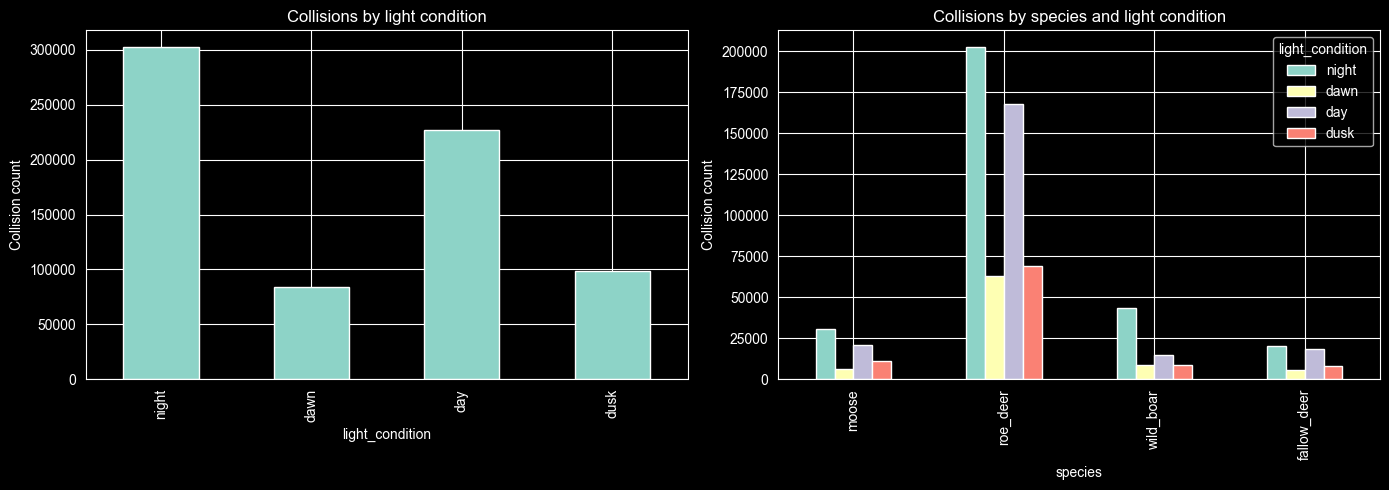

In [86]:
# 🌼🌈 EDA — stapeldiagram 📊 (◕‿◕✿)
light_order   = ["night", "dawn", "day", "dusk"]
species_order = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

daylight_df["light_condition"].value_counts().reindex(light_order).plot(
    kind="bar", ax=axes[0]
)
axes[0].set(ylabel="Collision count", title="Collisions by light condition")

(
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(species_order)
    .reindex(columns=light_order)
    .plot(kind="bar", ax=axes[1])
)
axes[1].set(ylabel="Collision count", title="Collisions by species and light condition")

plt.tight_layout()
plt.show()

In [87]:
# 🦄💕 kollar när älgarna strutar ut — gryning, dag, skymning, natt 🌙✨ → src/features.py · build_lagged_light
lagged_light = build_lagged_light(joined)

In [88]:
# 🌈🐱 hur många kraschar per art förra månaden? 🦌💨 → src/features.py · build_lagged_species
lagged_species = build_lagged_species(joined)

In [89]:
# 🌷🦄 vägar, järnväg, stängsel — hela hinderbanan för vilda djur!! akta älgarna 🚧 → src/infrastructure.py
paths = InfrastructurePaths(
    roads=Path(f"{DATA_DIR}/Sverige_Vägtrafiknät_GeoPackage/Sverige_Vägtrafiknät_194602.gpkg"),
    rail=Path(f"{DATA_DIR}/Järnvägnät_grundegenskaper/Järnvägsnät_grundegenskaper3_0_GeoPackage.gpkg"),
    fences=Path(f"{DATA_DIR}/Barrairanalys/Barriaranalys.gpkg"),
    speedlimit=Path(f"{DATA_DIR}/Speedlimit/ISA.gpkg"),
)
CACHE_DIR = Path(f"{DATA_DIR}/processed/cache")
infra = build_infrastructure_features(
    grid=grid, gdf_points=gdf, paths=paths, cache_dir=CACHE_DIR, use_cache=True,
)

model_df = (
    cell_month
    .merge(infra["roads"].drop(columns="geometry", errors="ignore"), on="cell_id", how="left")
    .query("road_length_m > 0")
)

model_df = model_df.merge(
    infra["rail"].drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id", how="left",
)
for col in ["rail_length_m", "rail_density", "nearest_rail_distance_m"]:
    model_df[col] = model_df[col].fillna(0)
model_df["rail_near_10km"] = (model_df["nearest_rail_distance_m"] < 10_000).astype(int)

model_df = model_df.merge(
    infra["fences"].drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id", how="left",
)
for col in ["fence_length_m", "fence_density", "nearest_fence_distance_m"]:
    model_df[col] = model_df[col].fillna(0)
model_df["fence_near_10km"] = (model_df["nearest_fence_distance_m"] < 10_000).astype(int)

model_df = model_df.merge(
    infra["speedlimit"].drop(columns="geometry", errors="ignore"),
    on="cell_id", how="left",
)
for col in [
    "speedlimit_mean_weighted", "speedlimit_max", "speedlimit_min",
    "speedlimit_90plus_share", "speedlimit_segment_length_m",
]:
    model_df[col] = model_df[col].fillna(0)

In [90]:
# 🦄💕 Orkestreringslogik — om du ändrar något här, gör samma ändring i scripts/train_final_model.py 🦄💕
relevant_cell_ids = model_df["cell_id"].unique()
grid_small = grid[grid["cell_id"].isin(relevant_cell_ids)]
print("Original grid:", grid.shape, "→ Filtered:", grid_small.shape)

temperature_features = build_cell_month_temperature(grid=grid_small)
model_df = model_df.merge(
    temperature_features[["cell_id", "period_start", "temp_mean", "temp_min", "temp_max"]],
    on=["cell_id", "period_start"],
    how="left",
)

precip_features = build_cell_month_precipitation(grid=grid_small)
model_df = model_df.merge(
    precip_features[["cell_id", "period_start", "precip_total"]],
    on=["cell_id", "period_start"],
    how="left",
)

model_df = model_df.dropna(
    subset=["temp_mean", "temp_min", "temp_max", "precip_total"]
).copy()

print(model_df[["precip_total"]].describe())


Original grid: (10419, 2) → Filtered: (4471, 2)
        precip_total
count  147828.000000
mean       44.911614
std        27.589264
min         1.400000
25%        24.100000
50%        41.000000
75%        60.400000
max       198.300000


In [91]:
# 🦄💕 Orkestreringslogik — om du ändrar något här, gör samma ändring i scripts/train_final_model.py 🦄💕
model_df = model_df.merge(lagged_species, on=["cell_id", "period_start"], how="left")
lag_cols = ["moose_lag1", "roe_deer_lag1", "wild_boar_lag1", "fallow_deer_lag1"]
for col in lag_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

model_df = model_df.merge(lagged_light, on=["cell_id", "period_start"], how="left")
light_lag_cols = [c for c in lagged_light.columns if c not in ["cell_id", "period_start"]]
for col in light_lag_cols:
    model_df[col] = model_df[col].fillna(0)

In [92]:
# 🌸🌈 jaktperioder, lek, cyklisk månad — allt det roliga ✨💕 → src/features.py
model_df = add_cyclical_month(model_df)
model_df = build_hunting_features(model_df)
model_df = build_rut_features(model_df)

model_df_clean = model_df.dropna(subset=FEATURES).copy()
print("After dropna:", model_df_clean.shape)
print(model_df_clean["period_start"].value_counts().sort_index())

After dropna: (147828, 45)
period_start
2015-01-01    1119
2015-02-01    1119
2015-03-01    1119
2015-04-01    1119
2015-05-01    1119
              ... 
2025-08-01    1119
2025-09-01    1119
2025-10-01    1119
2025-11-01    1119
2025-12-01    1119
Name: count, Length: 132, dtype: int64


In [93]:
# 🎀🦄 laddar hyperparametrar och delar upp 120 tidsfönster (˶ᵔ ᵕ ᵔ˶)♡ → src/models.py
hyperparameters = load_hyperparameters("../config/hyperparameters.yaml")

months = sorted(model_df_clean["period_start"].unique())
splits = make_expanding_time_splits(months, min_train_months=12, test_horizon=1)
print("Number of folds:", len(splits))

Number of folds: 120


In [94]:
# 🦄💖 LR och RF kämpar för sin plats 🤺 120 fönster av ren spänning!! → src/models.py · evaluate_time_splits ✿
results_df, oof_probs, oof_labels, mean_importance = evaluate_time_splits(
    model_df_clean, FEATURES, "risk", splits, hyperparameters,
)

print(results_df.head())

summary = (
    results_df.groupby("model")[["auc", "precision", "recall", "f1", "accuracy"]]
    .agg(["mean", "std"])
    .round(3)
)
print(summary)
print("\nMean feature importances across all folds:")
print(mean_importance)

joined["species"].value_counts(normalize=True)

   fold   model       auc  precision    recall        f1  accuracy
0     1  logreg  0.945644   0.341398  1.000000  0.509018  0.781055
1     1      rf  0.948823   0.780000  0.307087  0.440678  0.911528
2     2  logreg  0.953999   0.288288  0.969697  0.444444  0.857015
3     2      rf  0.950401   0.560000  0.212121  0.307692  0.943700
4     3  logreg  0.931885   0.218978  0.666667  0.329670  0.890974
          auc        precision        recall            f1        accuracy  \
         mean    std      mean    std   mean    std   mean    std     mean   
model                                                                        
logreg  0.955  0.007     0.433  0.078  0.943  0.048  0.590  0.077    0.850   
rf      0.957  0.010     0.780  0.075  0.453  0.137  0.561  0.123    0.923   

               
          std  
model          
logreg  0.027  
rf      0.016  

Mean feature importances across all folds:
roe_deer_lag1               0.179313
road_density                0.178494
night_lag

species
Rådjur         0.704946
Vildsvin       0.106177
Älg            0.097966
Dovhjort       0.073303
Övriga djur    0.006704
Kronhjort      0.006598
Utter          0.001777
Örn            0.001128
Lo             0.000660
Varg           0.000305
Björn          0.000279
Mufflonfår     0.000119
Järv           0.000038
Name: proportion, dtype: float64

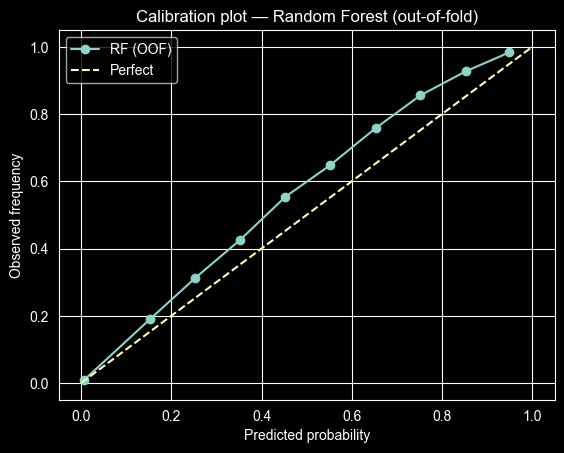

In [95]:
# 📈🌈 är modellen ärlig? kalibreringskurvan avslöjar allt 🐱 → src/visualisation.py · plot_calibration
fig, _ = plot_calibration(oof_probs, oof_labels)
plt.show()

In [96]:
# 🐱💕 tränar slutlig modell på ALL data — ingen vänder tillbaka nu!! 🦄✨ → src/models.py · fit_final_model
rf_final, rf_calibrated = fit_final_model(model_df_clean, FEATURES, "risk", hyperparameters)

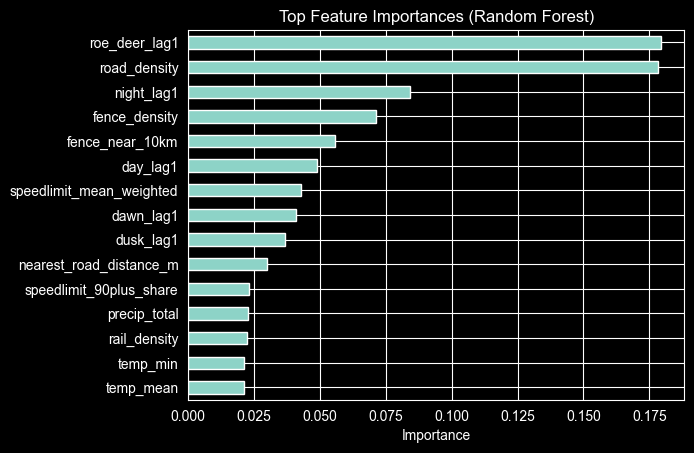

In [97]:
# 🎨🦄 vilka features är viktigast? topp 15 presenterar sig!! 👑 → src/visualisation.py · plot_top_features
fig, _ = plot_top_features(mean_importance, top_n=15)
plt.show()

In [98]:
# 🌼🐱 EDA — hastighetsgränser och korrelationer 🚗 (påverkar inte modellen) (◕‿◕✿)
model_df_clean[["speedlimit_mean_weighted", "speedlimit_max", "speedlimit_90plus_share"]].corr()


,speedlimit_mean_weighted,speedlimit_max,speedlimit_90plus_share
speedlimit_mean_weighted,1.000000,0.621258,0.211722
speedlimit_max,0.621258,1.000000,0.339485
speedlimit_90plus_share,0.211722,0.339485,1.000000


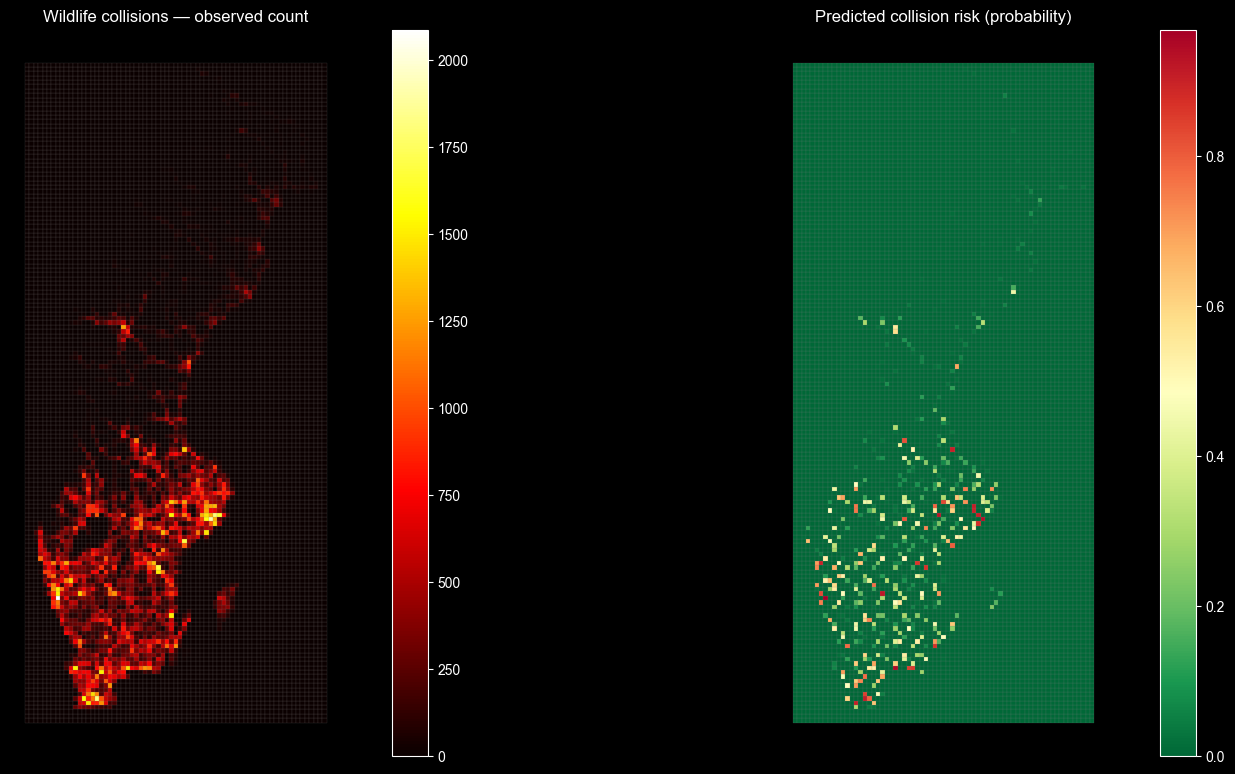

In [99]:
# 🗺️🌈 Sverige i all sin prakt — var är riskzonerna?? 🦄🌸 → src/visualisation.py · plot_spatial_risk_maps
fig, _ = plot_spatial_risk_maps(rf_final, model_df_clean, FEATURES, grid, joined)
model_df_clean["risk_prob"] = rf_final.predict_proba(model_df_clean[FEATURES])[:, 1]
plt.show()

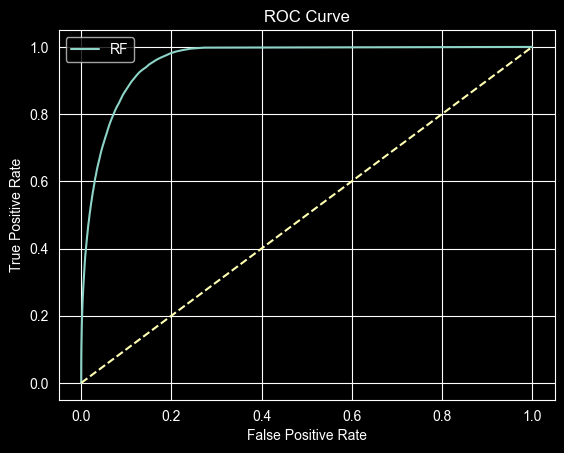

In [100]:
# 📉🦄 ROC-kurvan — hur bra är vi egentligen?? 🌈 fingers crossed!! → src/visualisation.py · plot_roc
fig, _ = plot_roc(oof_probs, oof_labels)
plt.show()

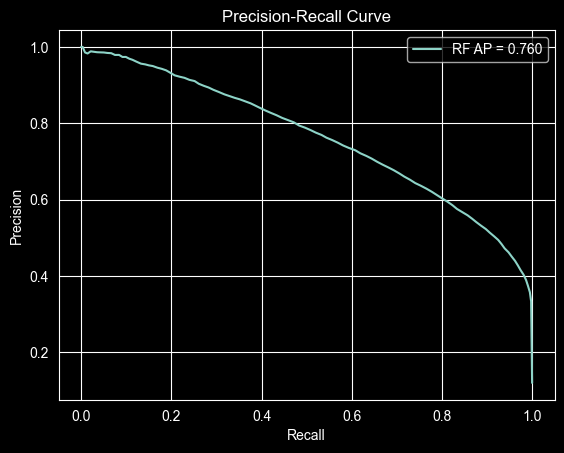

In [101]:
# 📉🌈 precision-recall — äntligen sanning!! (◕‿◕✿) 💕 → src/visualisation.py · plot_precision_recall
fig, _ = plot_precision_recall(oof_probs, oof_labels)
plt.show()

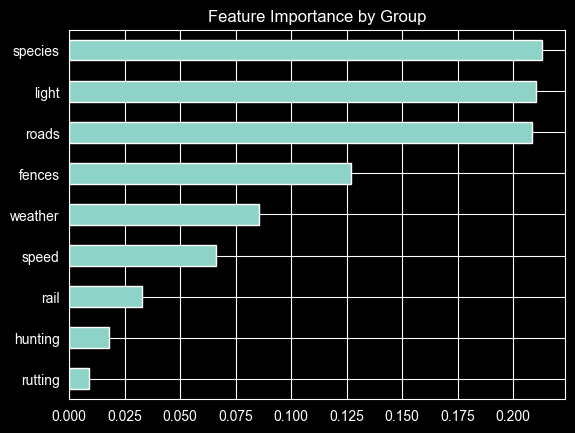

In [102]:
# 🎨🐱 feature importance per grupp — vad spelar roll för älgarna? 🦌✨ → src/visualisation.py · plot_feature_importance_by_group
fig, _ = plot_feature_importance_by_group(mean_importance, GROUPS)
plt.show()

/Users/alexwagner/Kod/GitHub/thesis_workspace/code/.venv/lib/python3.14/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


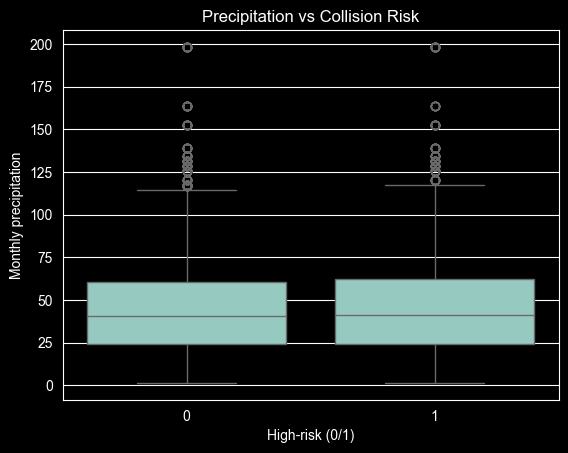

In [103]:
# 🌼🦄 EDA — regnar det mer när det kraschar? 🌧️ (påverkar inte modellen) (◕‿◕✿)
import seaborn as sns

sns.boxplot(x=model_df_clean["risk"], y=model_df_clean["precip_total"])
plt.xlabel("High-risk (0/1)")
plt.ylabel("Monthly precipitation")
plt.title("Precipitation vs Collision Risk")
plt.show()

In [104]:
# 💾🌈 sparar allt!! tre CSV:er till eftervärlden 🐱💕✨ → src/exports.py · export_artefacts
export_artefacts(model_df_clean, mean_importance, results_df, Path(f"{DATA_DIR}/processed"))

---

## Per-species analysis

Runs four separate models — one per species (roe deer, moose, wild boar, fallow deer).
Each species gets its own 75th-percentile risk threshold and feature subset.

All expensive data (infrastructure, weather, lags) is already in scope from the
pooled pipeline above — no re-loading. Helper functions defined inline here will
move to `src/` in T4 P6.

In [ ]:
# Per-species config — imported from src/config (T4 P6)
from config import SPECIES_LIST, SPECIES_LABELS, BASE_FEATURES_SPECIES, get_species_features

# Verify: 19 base features + 3 species-specific = 22 per species
print('BASE_FEATURES_SPECIES:', len(BASE_FEATURES_SPECIES), 'features')
print('moose total features:', len(get_species_features('moose')))

In [ ]:
# build_species_panel now lives in src/grid (T4 P6)
from grid import build_species_panel

In [ ]:
# build_species_model_df now lives in src/grid (T4 P6)
from grid import build_species_model_df

In [ ]:
# evaluate_time_splits_species replaced by models.evaluate_time_splits(return_lr_probs=True) (T4 P6)
# No inline function needed — the consolidated function is already imported in cell 1.

In [ ]:
SPECIES_OUTPUT_DIR = Path('../outputs/per_species')
species_results = {}

for species_name in SPECIES_LIST:
    print('\n' + '=' * 70)
    print(f'  {species_name}')
    print('=' * 70)

    df_s, features_s = build_species_model_df(species_name, joined, grid, model_df_clean)

    out_dir = SPECIES_OUTPUT_DIR / species_name
    out_dir.mkdir(parents=True, exist_ok=True)

    months_s = sorted(df_s['period_start'].unique())
    splits_s = make_expanding_time_splits(months_s, min_train_months=12, test_horizon=1)

    res_df, oof_rf, oof_lr, oof_lbl, mean_imp = evaluate_time_splits(
        df_s, features_s, 'risk', splits_s, hyperparameters, return_lr_probs=True
    )

    summary = (
        res_df.groupby('model')[['auc', 'precision', 'recall', 'f1', 'accuracy']]
        .agg(['mean', 'std'])
        .round(3)
    )
    print(summary)
    print(mean_imp)

    res_df.to_csv(out_dir / f'cv_results_{species_name}.csv', index=False)
    mean_imp.to_csv(out_dir / f'feature_importance_{species_name}.csv')
    df_s.to_csv(out_dir / f'model_df_{species_name}.csv', index=False)

    species_results[species_name] = {
        'df': df_s, 'features': features_s, 'results': res_df,
        'summary': summary, 'oof_rf': oof_rf, 'oof_lr': oof_lr,
        'oof_labels': oof_lbl, 'importance': mean_imp,
    }

species_comparison = pd.DataFrame([
    {
        'species': sp, 'model': model,
        'auc_mean': species_results[sp]['summary'].loc[model, ('auc', 'mean')],
        'auc_std':  species_results[sp]['summary'].loc[model, ('auc', 'std')],
        'f1_mean':  species_results[sp]['summary'].loc[model, ('f1',  'mean')],
        'recall_mean': species_results[sp]['summary'].loc[model, ('recall', 'mean')],
    }
    for sp in SPECIES_LIST for model in ['logreg', 'rf']
])
print('\n=== Species comparison ===')
print(species_comparison.to_string(index=False))
species_comparison.to_csv(SPECIES_OUTPUT_DIR / 'species_comparison.csv', index=False)

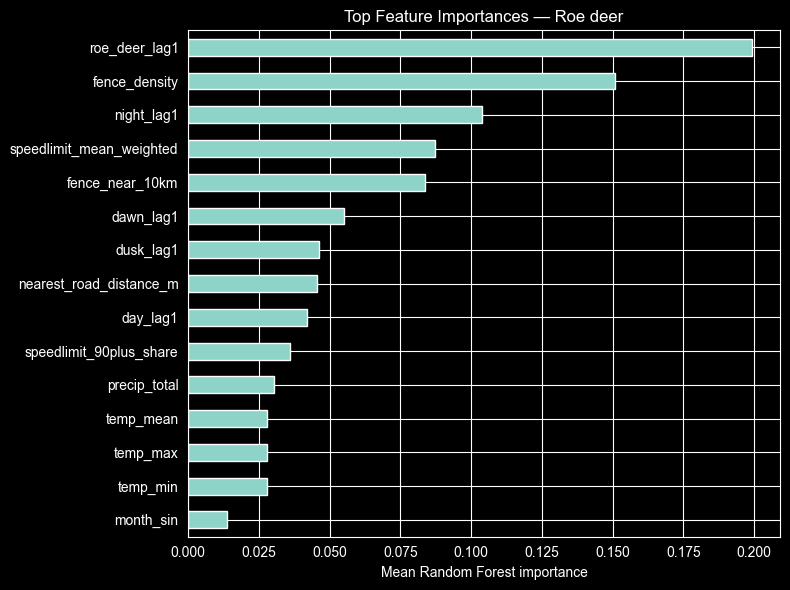

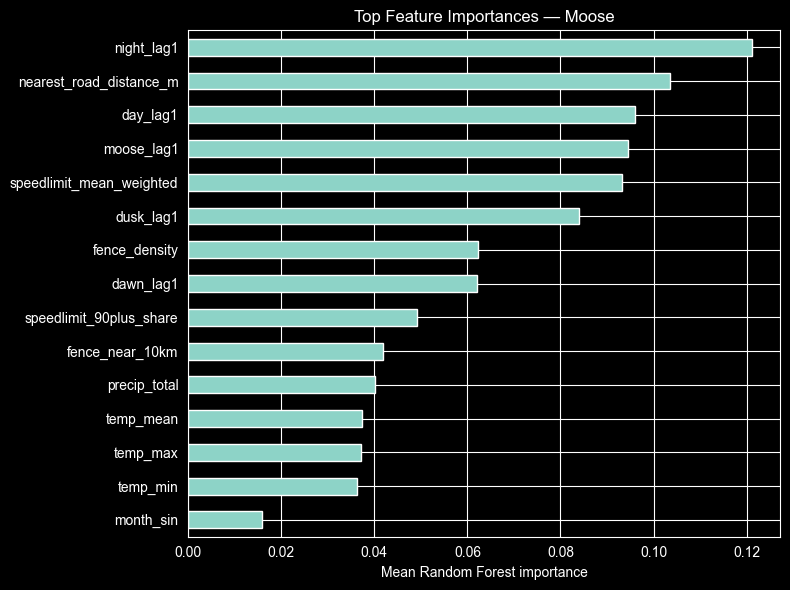

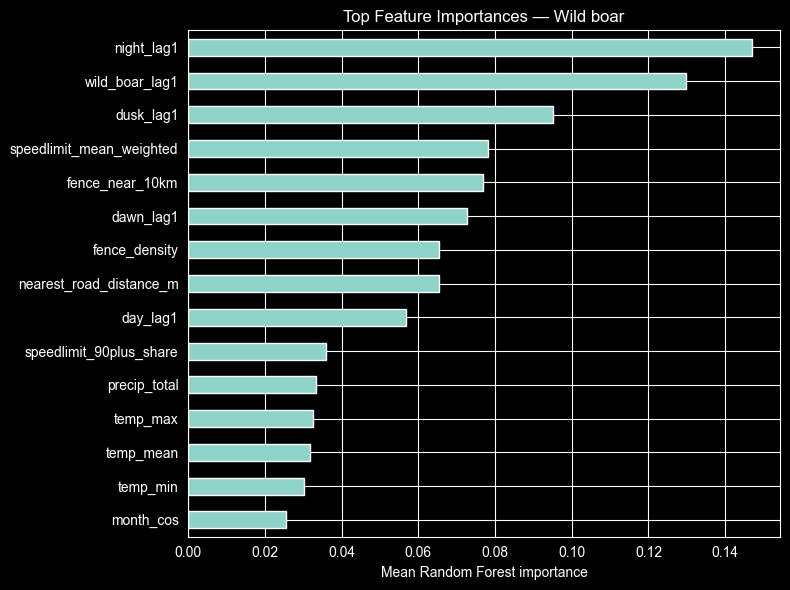

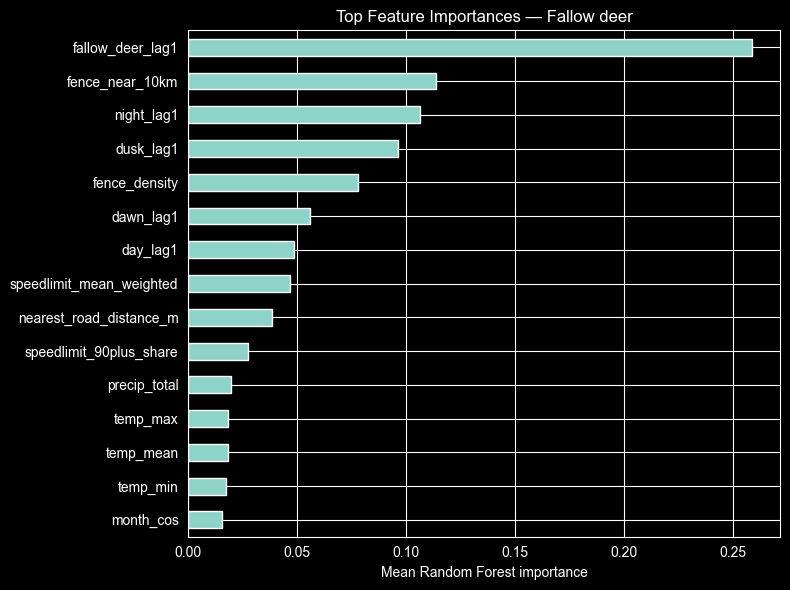

In [110]:
for species_name, data in species_results.items():
    out_dir = SPECIES_OUTPUT_DIR / species_name
    plt.figure(figsize=(8, 6))
    data["importance"].head(15).sort_values().plot(kind="barh")
    plt.title(f"Top Feature Importances — {SPECIES_LABELS[species_name]}")
    plt.xlabel("Mean Random Forest importance")
    plt.tight_layout()
    plt.savefig(out_dir / f"feature_importance_{species_name}.pdf")
    plt.show()

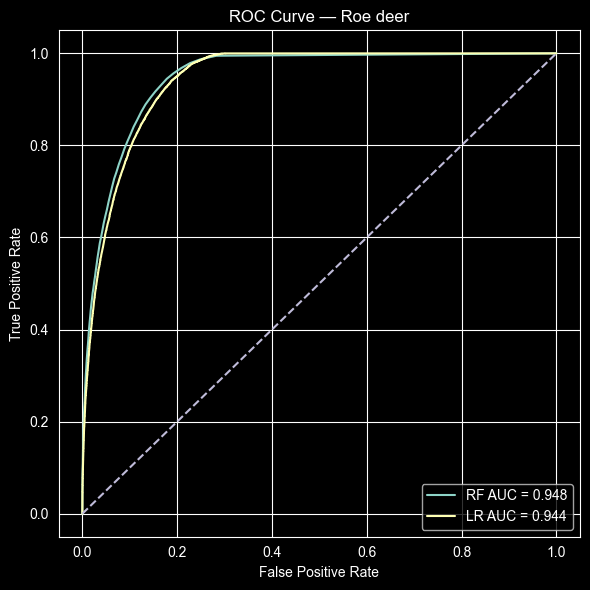

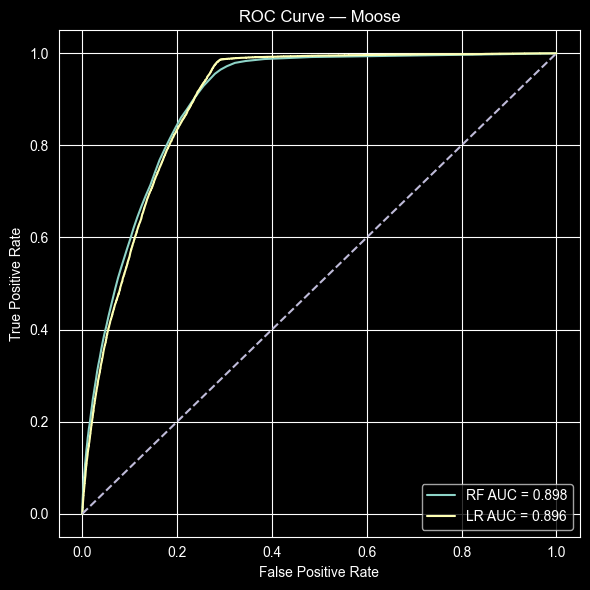

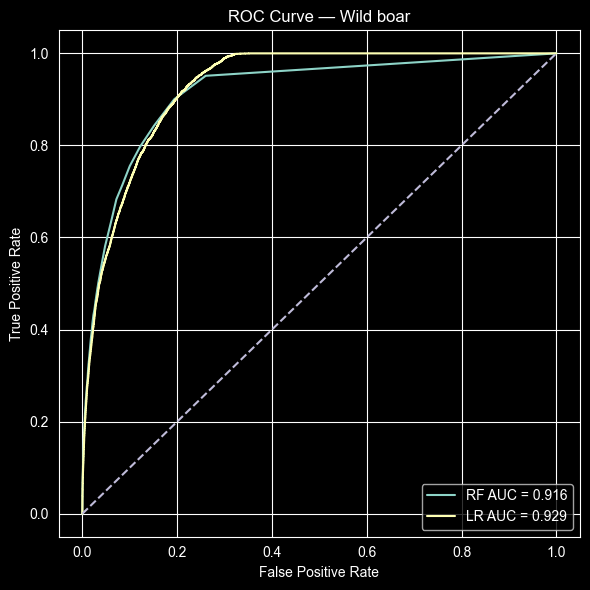

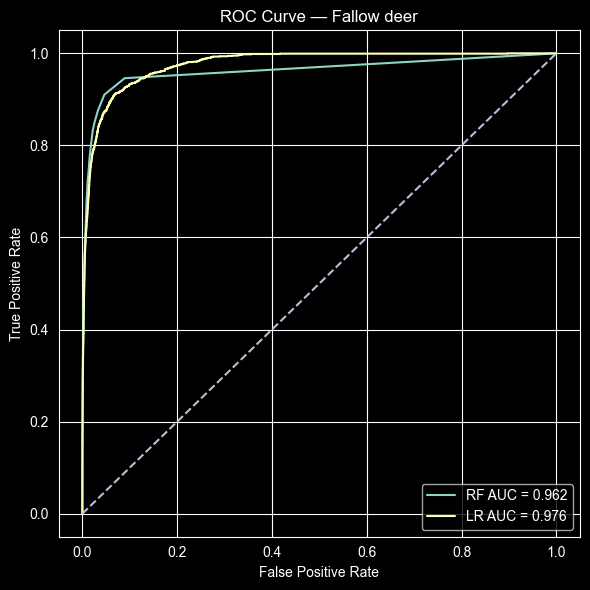

In [111]:
for species_name, data in species_results.items():
    out_dir = SPECIES_OUTPUT_DIR / species_name
    fpr_rf, tpr_rf, _ = roc_curve(data["oof_labels"], data["oof_rf"])
    fpr_lr, tpr_lr, _ = roc_curve(data["oof_labels"], data["oof_lr"])
    auc_rf = roc_auc_score(data["oof_labels"], data["oof_rf"])
    auc_lr = roc_auc_score(data["oof_labels"], data["oof_lr"])

    plt.figure(figsize=(6, 6))
    plt.plot(fpr_rf, tpr_rf, label=f"RF AUC = {auc_rf:.3f}")
    plt.plot(fpr_lr, tpr_lr, label=f"LR AUC = {auc_lr:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {SPECIES_LABELS[species_name]}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / f"roc_{species_name}.pdf")
    plt.show()

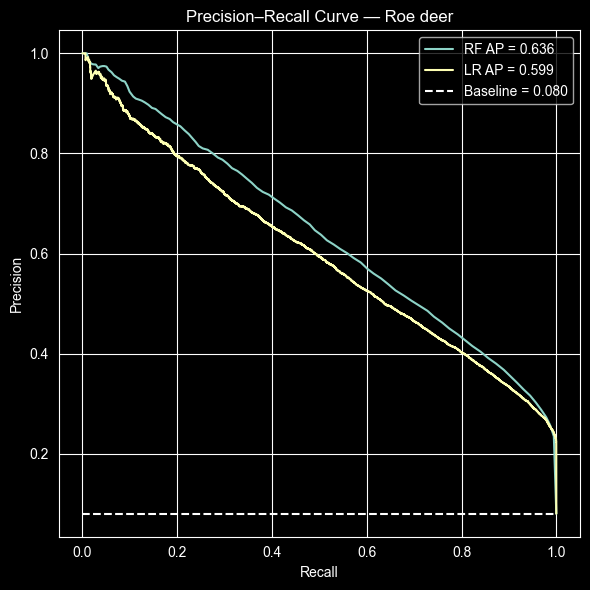

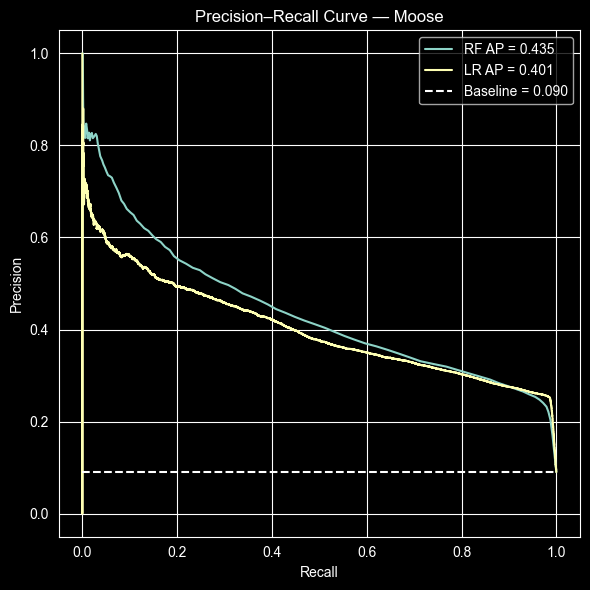

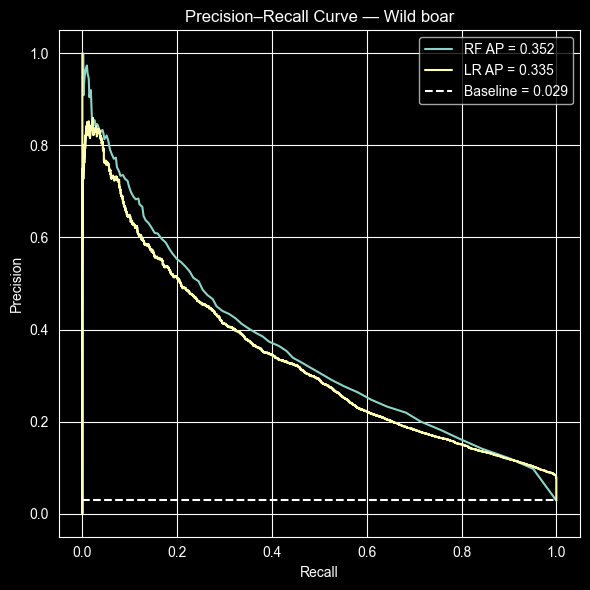

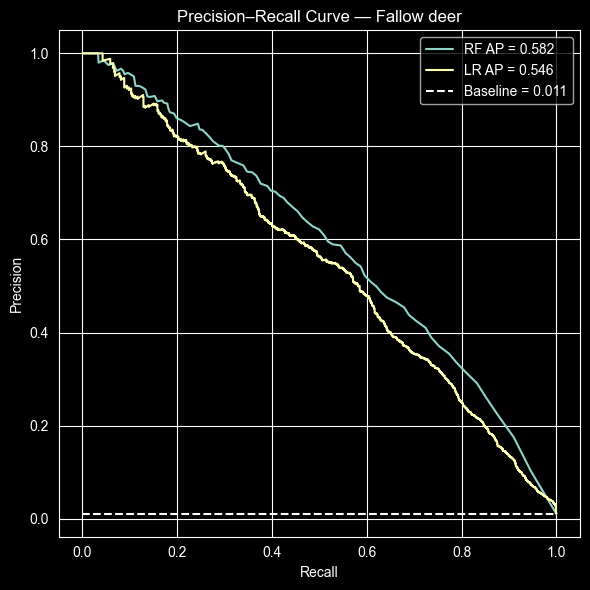

In [112]:
for species_name, data in species_results.items():
    out_dir = SPECIES_OUTPUT_DIR / species_name
    prec_rf, rec_rf, _ = precision_recall_curve(data["oof_labels"], data["oof_rf"])
    prec_lr, rec_lr, _ = precision_recall_curve(data["oof_labels"], data["oof_lr"])
    ap_rf = average_precision_score(data["oof_labels"], data["oof_rf"])
    ap_lr = average_precision_score(data["oof_labels"], data["oof_lr"])
    baseline = data["oof_labels"].mean()

    plt.figure(figsize=(6, 6))
    plt.plot(rec_rf, prec_rf, label=f"RF AP = {ap_rf:.3f}")
    plt.plot(rec_lr, prec_lr, label=f"LR AP = {ap_lr:.3f}")
    plt.hlines(baseline, 0, 1, linestyles="--", label=f"Baseline = {baseline:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {SPECIES_LABELS[species_name]}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / f"pr_{species_name}.pdf")
    plt.show()

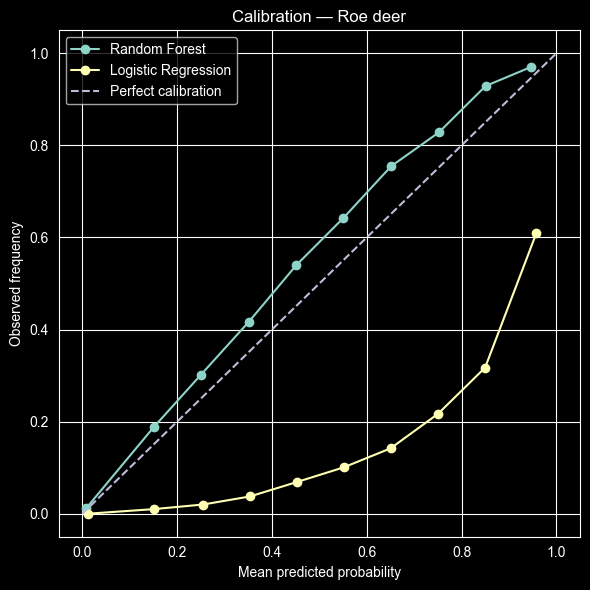

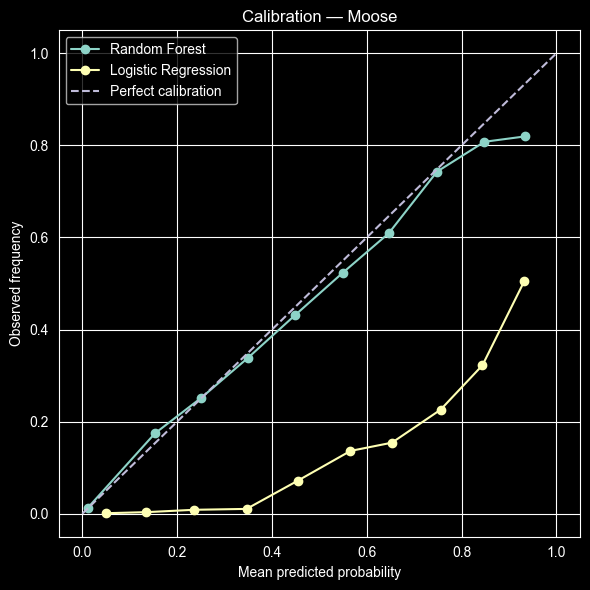

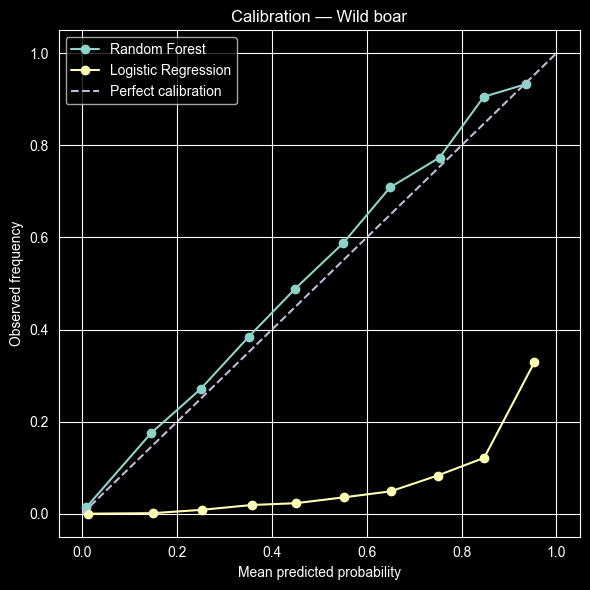

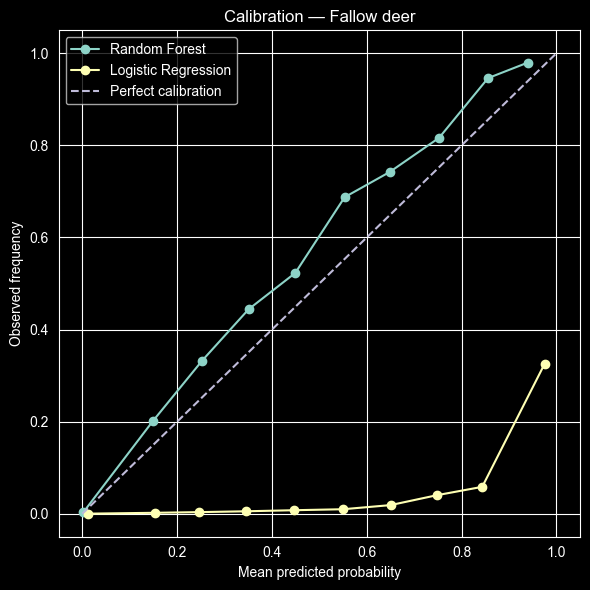

In [113]:
for species_name, data in species_results.items():
    out_dir = SPECIES_OUTPUT_DIR / species_name
    prob_true_rf, prob_pred_rf = calibration_curve(
        data["oof_labels"], data["oof_rf"], n_bins=10, strategy="uniform")
    prob_true_lr, prob_pred_lr = calibration_curve(
        data["oof_labels"], data["oof_lr"], n_bins=10, strategy="uniform")

    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")
    plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="Logistic Regression")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration — {SPECIES_LABELS[species_name]}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / f"calibration_{species_name}.pdf")
    plt.show()

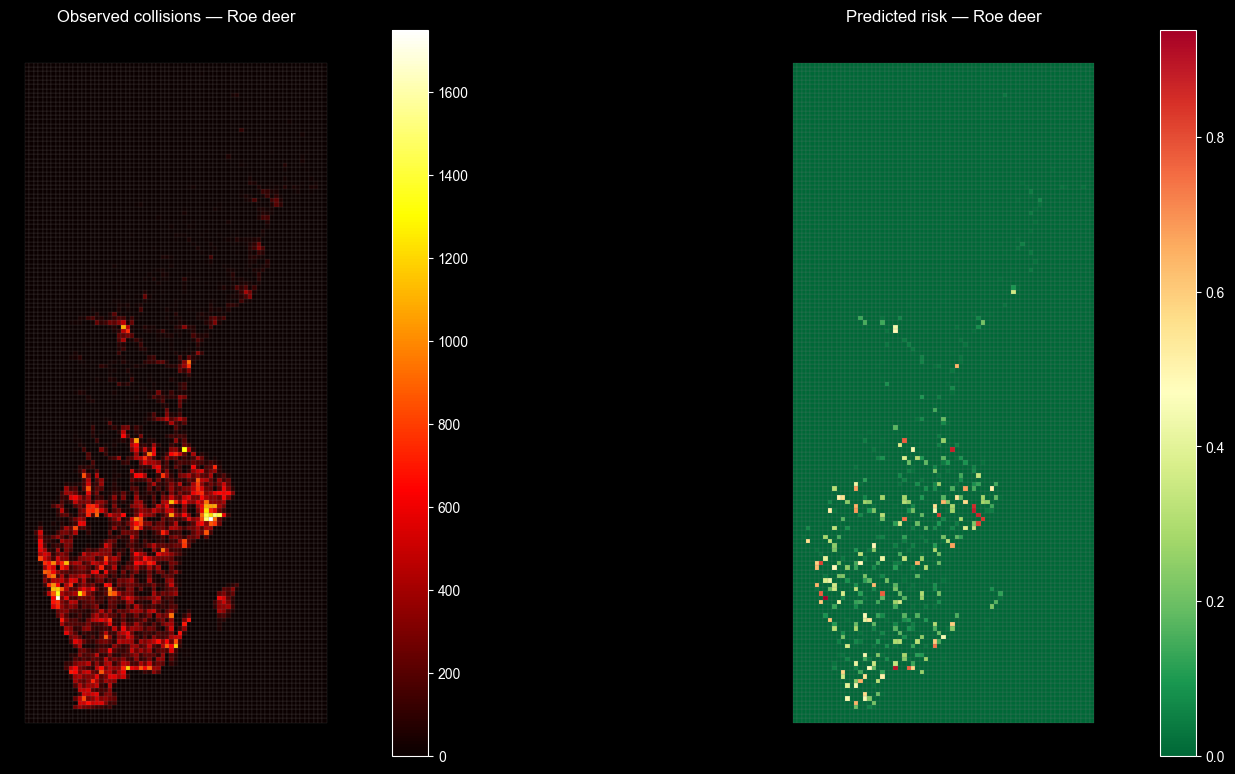

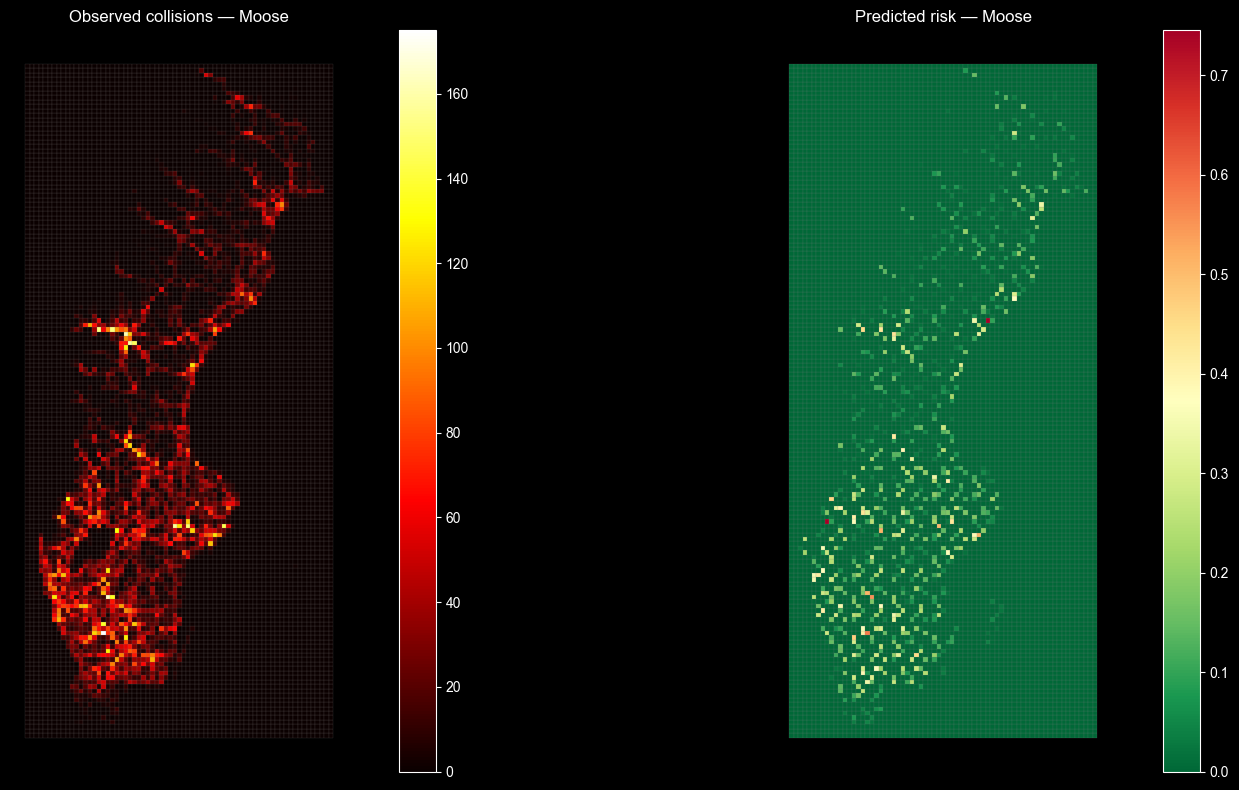

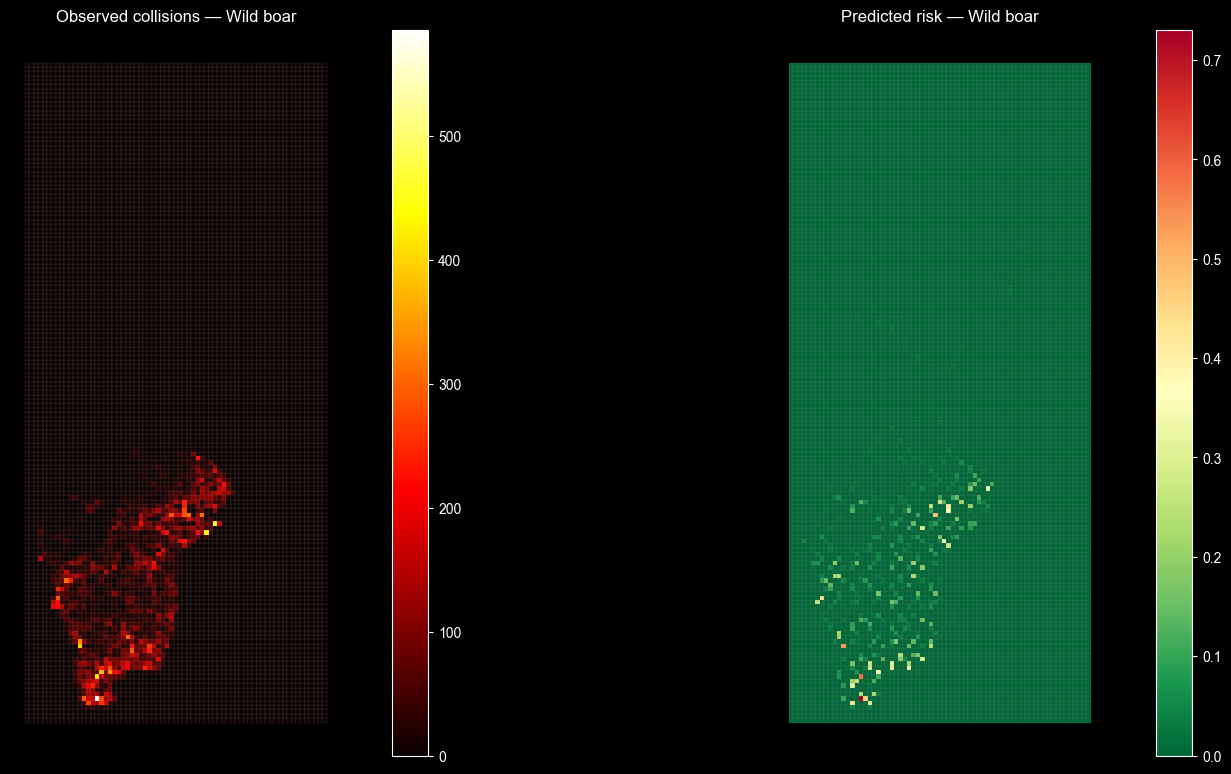

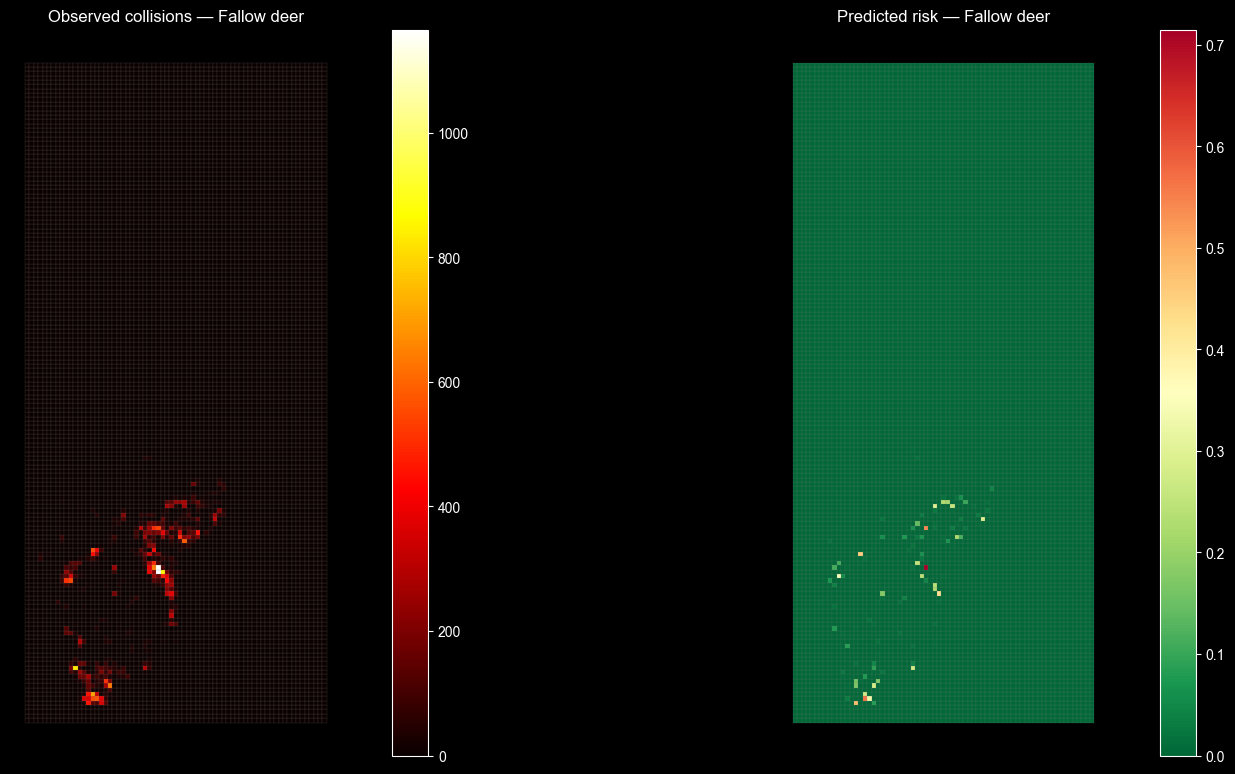

In [114]:
from sklearn.ensemble import RandomForestClassifier as RFC

for species_name, data in species_results.items():
    out_dir = SPECIES_OUTPUT_DIR / species_name
    df_s = data["df"].copy()
    features_s = data["features"]

    rf_s = RFC(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
    rf_s.fit(df_s[features_s], df_s["risk"])
    df_s["risk_prob"] = rf_s.predict_proba(df_s[features_s])[:, 1]

    cell_risk = df_s.groupby("cell_id")["risk_prob"].mean().reset_index()
    grid_risk = grid.merge(cell_risk, on="cell_id", how="left")
    grid_risk["risk_prob"] = grid_risk["risk_prob"].fillna(0)

    sp_joined = joined.copy()
    sp_joined["species_clean"] = (
        sp_joined["species"].astype(str).str.strip().str.lower().replace(SPECIES_MAP)
    )
    cell_totals = (
        sp_joined[sp_joined["species_clean"] == species_name]
        .groupby("cell_id").size().reset_index(name="collision_count")
    )
    grid_heatmap = grid.merge(cell_totals, on="cell_id", how="left")
    grid_heatmap["collision_count"] = grid_heatmap["collision_count"].fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    grid_heatmap.plot(column="collision_count", cmap="hot",
                      linewidth=0.1, edgecolor="grey", legend=True, ax=axes[0])
    axes[0].set_title(f"Observed collisions — {SPECIES_LABELS[species_name]}")
    axes[0].set_axis_off()
    grid_risk.plot(column="risk_prob", cmap="RdYlGn_r",
                   linewidth=0.1, edgecolor="grey", legend=True, ax=axes[1])
    axes[1].set_title(f"Predicted risk — {SPECIES_LABELS[species_name]}")
    axes[1].set_axis_off()
    plt.tight_layout()
    plt.savefig(out_dir / f"risk_map_{species_name}.pdf")
    plt.show()